# Base Python File

In [1]:
# Import Packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns

In [2]:
# Create timestamp and author
from datetime import datetime 
time_now=datetime.now().strftime('%m_%d_%Y_%I%M%p')
print("Current Time:{}".format(time_now))
print("Tina Pham")

Current Time:09_26_2026_0323PM
Tina Pham


In [4]:
# Read the dataset and store it as data2026
data2026=pd.read_csv('2026PartYear.csv',encoding='utf-8')
data2025 = pd.read_csv('2025.csv', encoding='utf-8')

In [28]:
# Safely filter 2025 data to Periods 1-8 / Weeks 1-32
if "Week" in data2025.columns: data2025 = data2025[data2025["Week"].astype(str).str.extract(r"(\d+)")[0].astype(int) <= 32].copy()
elif "Period" in data2025.columns:
    data2025 = data2025[data2025["Period"] <= 8].copy()
elif "Date" in data2025.columns:
    data2025["Date"] = pd.to_datetime(data2025["Date"])
    data2025_filtered = data2025[data2025["Date"].dt.isocalendar().week <= 32].copy()

In [26]:
# Calculate Revenue
data2025["Revenue"] = (data2025["ASP Current Year"]* data2025["Total Bulk and Bags"])
data2026["Revenue"] = (data2026["ASP Current Year"] * data2026["Total Bulk and Bags"])

# Overall YoY Market Performance

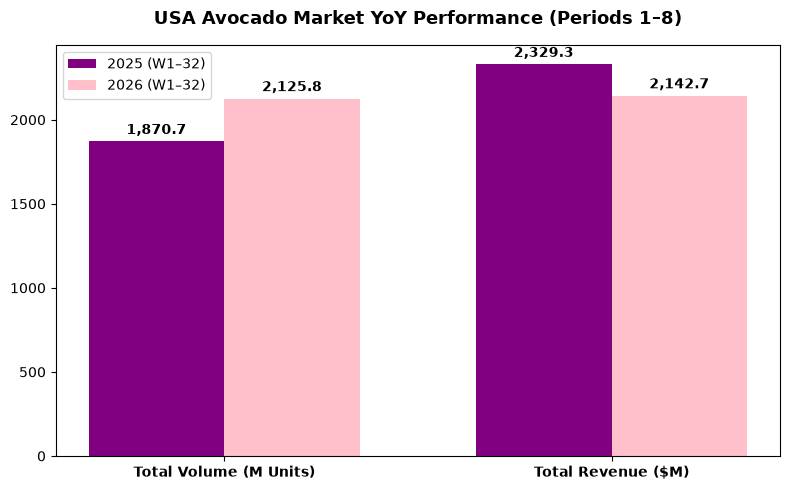

In [41]:
fig, ax1 = plt.subplots(figsize=(8, 5))
categories = ["Total Volume (M Units)", "Total Revenue ($M)"]
x = np.arange(len(categories))
width = 0.35

vals_2025 = [1870.70, 2329.30]
vals_2026 = [2125.80, 2142.66]

rects1 = ax1.bar( x - width / 2, vals_2025, width, label="2025 (W1–32)", color="Purple")
rects2 = ax1.bar( x + width / 2, vals_2026, width, label="2026 (W1–32)", color="Pink")

ax1.set_title("USA Avocado Market YoY Performance (Periods 1–8)", fontsize=13, fontweight="bold", pad=15)

ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontweight="bold")
ax1.legend()

for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(f"{h:,.1f}",(p.get_x() + p.get_width() / 2.0, h), ha="center", va="bottom", xytext=(0, 3), textcoords="offset points", fontweight="bold")

plt.tight_layout()
plt.show()

# Product Type Breakdown

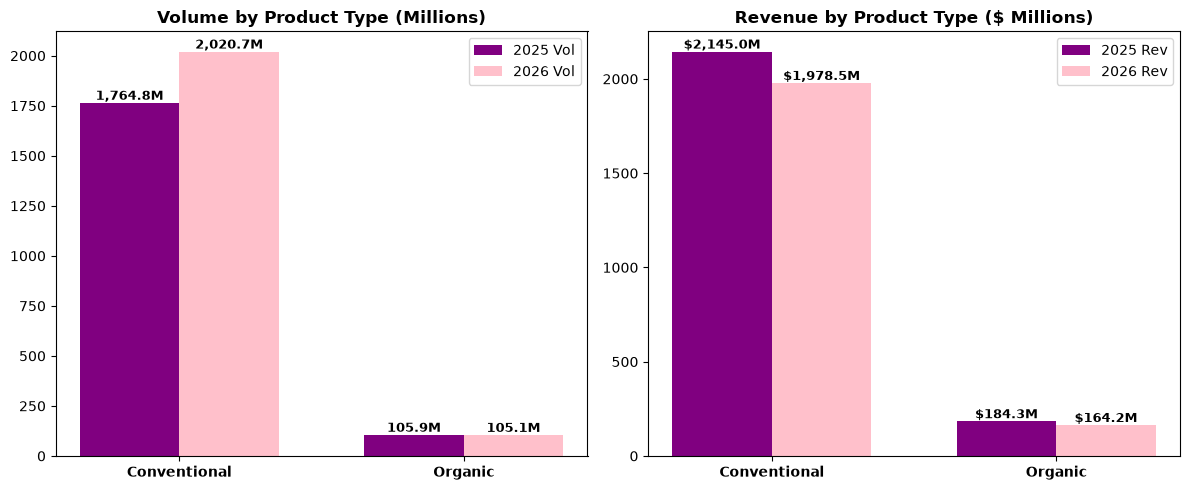

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
types = ["Conventional", "Organic"]
vol_2025, vol_2026 = [1764.84, 105.86], [2020.68, 105.12]
rev_2025, rev_2026 = [2145.04, 184.27], [1978.50, 164.16]
x = np.arange(len(types))

# Volume Plot
ax1.bar(x - width / 2, vol_2025, width, label="2025 Vol", color="Purple")
ax1.bar(x + width / 2, vol_2026, width, label="2026 Vol", color="Pink")
ax1.set_title("Volume by Product Type (Millions)", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(types, fontweight="bold")
ax1.legend()

for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(f"{h:,.1f}M", (p.get_x() + p.get_width() / 2.0, h), ha="center", va="bottom", fontsize=9, fontweight="bold")

# Revenue Plot
ax2.bar(x - width / 2, rev_2025, width, label="2025 Rev", color="Purple")
ax2.bar(x + width / 2, rev_2026, width, label="2026 Rev", color="Pink")
ax2.set_title("Revenue by Product Type ($ Millions)", fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(types, fontweight="bold")
ax2.legend()

for p in ax2.patches:
    h = p.get_height()
    if h > 0:
        ax2.annotate(f"${h:,.1f}M", (p.get_x() + p.get_width() / 2.0, h), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

# ASP

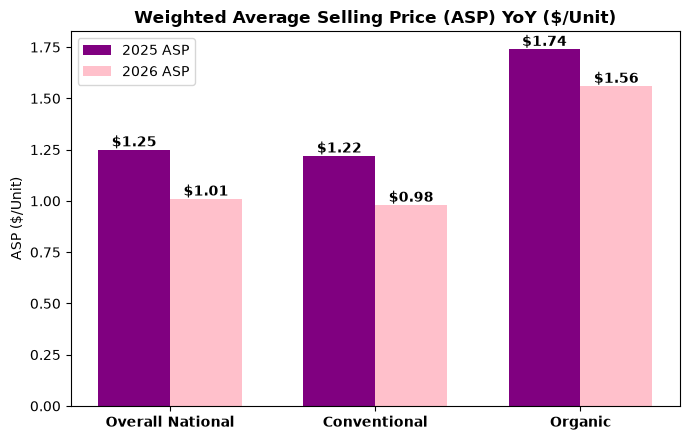

In [34]:
fig, ax = plt.subplots(figsize=(7, 4.5))
asp_2025 = [1.25, 1.22, 1.74]
asp_2026 = [1.01, 0.98, 1.56]
labels = ["Overall National", "Conventional", "Organic"]
x = np.arange(len(labels))

ax.bar(x - width / 2, asp_2025, width, label="2025 ASP", color="Purple")
ax.bar(x + width / 2, asp_2026, width, label="2026 ASP", color="Pink")

ax.set_title("Weighted Average Selling Price (ASP) YoY ($/Unit)", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight="bold")
ax.set_ylabel("ASP ($/Unit)")
ax.legend()

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"${h:.2f}", (p.get_x() + p.get_width() / 2.0, h), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()